In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1')
             .replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    
    for i in range(len(matrix_list)): 
        # Pad matrices to the maximum sequence length
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list), max_len)
    return matrix, mask

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)
    return pd.DataFrame(merged_rows)

def cluster_virus(df, vector, drop_duplicate=False, method="pca", random_state=42):

    if drop_duplicate:
        df_arr = pd.DataFrame(vector, columns=[f'col_{i}' for i in range(vector.shape[1])])
        df_merged = pd.concat([df.reset_index(drop=True), df_arr], axis=1)
        df_merged["virusDate"] = pd.to_datetime(df_merged["virusDate"], errors="coerce")
        
        aggregate_dict = {col: 'first' for col in df_merged.columns if col != 'seq_c'}
        aggregate_dict['virusDate'] = 'min'
        df_agg = df_merged.groupby('seq_c').agg(aggregate_dict).reset_index()
        df = df_agg.iloc[:, :-vector.shape[1]]
        vector = np.array(df_agg.iloc[:, -vector.shape[1]:])

    method = method.lower()

    if method == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
        X_2d = reducer.fit_transform(vector)

    elif method in ["tsne", "t-sne"]:
        reducer = TSNE(
            n_components=2,
            random_state=random_state,
            init="pca",
            learning_rate="auto",
            perplexity=30,
        )
        X_2d = reducer.fit_transform(vector)

    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    k = 2
    labels = KMeans(n_clusters=k, random_state=441).fit_predict(X_2d)
    
    df_plot = pd.DataFrame(X_2d, columns=['x', 'y'])
    df_plot['cluster'] = labels.astype(str)
    df_plot['type'] = df['Type'].tolist()
    df_plot['virusDate'] = df['virusDate']
    df_plot['virusIslID'] = df['virusIslID'].tolist()
    df_plot['method'] = method

    return df_plot

def plot_virus_scatter(df_plot, color_map=None, save_path=None):
    plt.figure(figsize=(5, 3.5))

    order = ['Crick', 'CDC', 'CNIC']  # Desired plotting order

    for t in order:
        subdf = df_plot[df_plot['type'] == t]  # Select data for this type
        if len(subdf) == 0:
            continue  # Skip missing types

        plt.scatter(subdf["x"], subdf["y"],
                    label=t,
                    c=color_map.get(t, "gray"),
                    s=8, alpha=0.45, lw=0)

    # ===== Styling =====
    plt.xlabel("component-1", fontsize=14)
    plt.ylabel("component-2", fontsize=14)
    
    plt.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(0.98, 1), 
    markerscale=2, alignment='left')

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    if save_path is not None:
        ext = os.path.splitext(save_path)[1].lower()

        if ext == '.png':
            plt.savefig(save_path, dpi=600, transparent=True,
                        pil_kwargs={"compress_level": 0}, bbox_inches="tight")
        elif ext == '.svg':
            plt.savefig(save_path, format='svg', bbox_inches="tight")
    else:
        plt.show()

def plot_virus_scatter_time(df_plot, save_path=None, add_centroid=True, label_centroid=True, color_quantile=(0.05, 0.95)):
    """
    Plot points by virusDate using a light-to-dark color scale, with optional yearly centroids.
    """
    fig, ax = plt.subplots(figsize=(6, 3.5))

    # Parse dates and remove invalid values
    df_plot = df_plot.copy()
    df_plot["virusDate"] = pd.to_datetime(df_plot["virusDate"], errors="coerce")
    df_plot = df_plot.dropna(subset=["virusDate"])
    if df_plot.empty:
        raise ValueError("virusDate contains only missing or unparsable dates")

    # Sort by date so later points are drawn on top of earlier points
    df_plot = df_plot.sort_values("virusDate")

    # Normalize dates using quantiles to reduce color-scale compression by outliers
    vmin = df_plot["virusDate"].quantile(color_quantile[0]).timestamp()
    vmax = df_plot["virusDate"].quantile(color_quantile[1]).timestamp()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # colormap
    cmap = plt.get_cmap("cividis")

    # Main scatter layer
    ax.scatter(
        df_plot["x"], df_plot["y"],
        c=df_plot["virusDate"].apply(lambda x: x.timestamp()),
        cmap=cmap, norm=norm,
        s=6, alpha=0.4, lw=0, zorder=1
    )

    # Yearly centroid layer
    if add_centroid:
        df_plot["year"] = df_plot["virusDate"].dt.year

        year_centroids = (
            df_plot.groupby("year", as_index=False)
            .agg(
                x_centroid=("x", "mean"),
                y_centroid=("y", "mean"),
                n=("x", "size")
            )
            .sort_values("year")
        )

        # Optional: remove years with too few samples to reduce outlier-driven trajectories
        # year_centroids = year_centroids[year_centroids["n"] >= 5].copy()

        # Use mid-year dates for centroid color mapping
        year_centroids["year_date"] = pd.to_datetime(year_centroids["year"].astype(str) + "-07-01")
        year_centroids["year_ts"] = year_centroids["year_date"].apply(lambda x: x.timestamp())

        # Connecting line
        ax.plot(
            year_centroids["x_centroid"],
            year_centroids["y_centroid"],
            color="0.35",
            lw=1.5,
            alpha=0.8,
            zorder=3
        )

        # Centroid points
        ax.scatter(
            year_centroids["x_centroid"],
            year_centroids["y_centroid"],
            c=year_centroids["year_ts"],
            cmap=cmap,
            norm=norm,
            s=22,
            edgecolor="black",
            linewidth=0.9,
            zorder=4
        )

        # Optional year labels
        if label_centroid:
            for _, row in year_centroids.iterrows():
                ax.text(
                    row["x_centroid"] + 0.002,
                    row["y_centroid"] + 0.002,
                    str(int(row["year"])),
                    fontsize=10,
                    color="0.25",
                    zorder=5
                )

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    ticks = np.linspace(vmin, vmax, 5)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))
    cbar.set_label("Isolation year", fontsize=10)

    # Styling
    ax.set_xlabel("PC1", fontsize=10)
    ax.set_ylabel("PC2", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(labelsize=8, length=3)

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=600,
            transparent=True,
            bbox_inches="tight",
            pil_kwargs={"compress_level": 0}
        )
    else:
        plt.show()

def plot_virus_scatter_time_nature(df_plot, save_path=None, title=None):
    """
    Nature-style scatter by virusDate.

    Parameters
    ----------
    df_plot : pd.DataFrame
        Must contain the ['x', 'y', 'virusDate'] columns.
    save_path : str or None
        Output path. Supports .png and .svg. If None, display the plot directly.
    title : str or None
        Optional title.
    """
    required_cols = {"x", "y", "virusDate"}
    missing = required_cols - set(df_plot.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # Copy data and clean dates
    d = df_plot.copy()
    d["virusDate"] = pd.to_datetime(d["virusDate"], errors="coerce")
    d = d.dropna(subset=["virusDate", "x", "y"]).sort_values("virusDate")
    if d.empty:
        raise ValueError("No valid data remain: check that virusDate, x, and y are parsable")

    # Use local style settings to avoid modifying global rcParams
    with plt.style.context("default"):
        plt.rcParams.update({
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
        })

        fig, ax = plt.subplots(figsize=(5.1, 3.6), dpi=260)

        # Use quantiles to reduce the influence of extreme years on the color scale
        t = d["virusDate"].map(pd.Timestamp.timestamp).to_numpy()
        vmin, vmax = np.quantile(t, [0.03, 0.97])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap("cividis")

        ax.scatter(
            d["x"],
            d["y"],
            c=t,
            cmap=cmap,
            norm=norm,
            s=15,
            alpha=0.86,
            linewidths=0.22,
            edgecolors="white",
            rasterized=True,
            zorder=2,
        )

        # Light grid and clean axes
        ax.grid(True, linestyle="-", linewidth=0.45, alpha=0.16, color="#8a8a8a")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)
        ax.tick_params(direction="out", width=0.8, length=3)

        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        if title:
            ax.set_title(title, pad=5)

        # Narrow colorbar for a publication-style layout
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.92)
        ticks = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))
        cbar.set_label("Collection year", fontsize=8.8)
        cbar.ax.tick_params(labelsize=8)
        cbar.outline.set_linewidth(0.6)

        plt.tight_layout(pad=0.6)

        if save_path:
            ext = os.path.splitext(save_path)[1].lower()
            if ext == ".svg":
                plt.savefig(save_path, format="svg", bbox_inches="tight", transparent=True)
            else:
                plt.savefig(
                    save_path,
                    dpi=600,
                    bbox_inches="tight",
                    transparent=True,
                    pil_kwargs={"compress_level": 0},
                )
        else:
            plt.show()


## Data loading

In [2]:
# All_data = pd.read_csv('../../data/reverse_test/processed/All.csv')

# # load embedding
# Crick_df = All_data[(All_data['seq_a'].str.len() >= 566) & (All_data['seq_c'].str.len() >= 566)]
# sequence_names = pd.concat([Crick_df['seq_id_a'], Crick_df['seq_id_c']]).unique().tolist()
# sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
# emb_dict_Crick = load_embedding("../../data/reverse_test/embedding/", files=sequence_names)

# Crick_vector = np.stack([np.asarray(emb_dict_Crick['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in Crick_df['seq_id_c']])

## Viral evolution visualization

In [3]:
# Crick_df.to_csv('Evolution_data.csv', index=False)
# np.save("Evolution_vectors.npy", Crick_vector)
Crick_df = pd.read_csv('./deprecated/Evolution_data.csv')
Crick_vector = np.load('./deprecated/Evolution_vectors.npy')

In [4]:
plot_df = cluster_virus(Crick_df, Crick_vector, drop_duplicate=True, method="PCA")

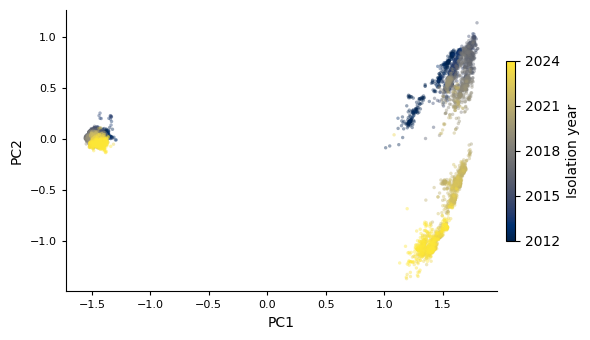

In [5]:
plot_df_filt = plot_df
plot_virus_scatter_time(plot_df_filt, add_centroid=False)

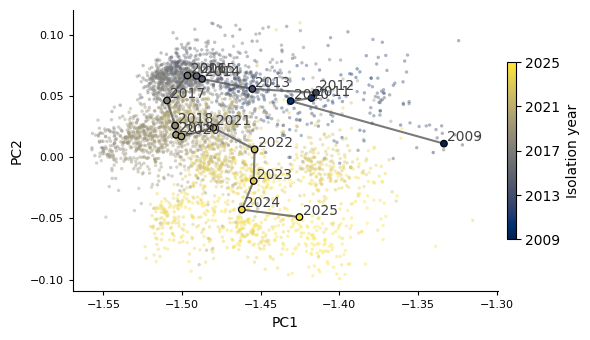

In [6]:
plot_df_filt = plot_df[plot_df['type'].isin(['H1N1', 'H1N1_2024NH', 'H1N1_2024SH', 'H1N1_2025NH'])]
plot_df_filt = plot_df_filt[plot_df_filt['x'] < -1.3]
plot_df_filt = plot_df_filt[(plot_df_filt['y'] < 0.11) & (plot_df_filt['y'] > -0.1)]
# plot_virus_scatter_time(plot_df_filt, color_quantile=(0, 1), label_centroid=False, save_path='H1N1_evo.png')
plot_virus_scatter_time(plot_df_filt, add_centroid=True, color_quantile=(0, 1))

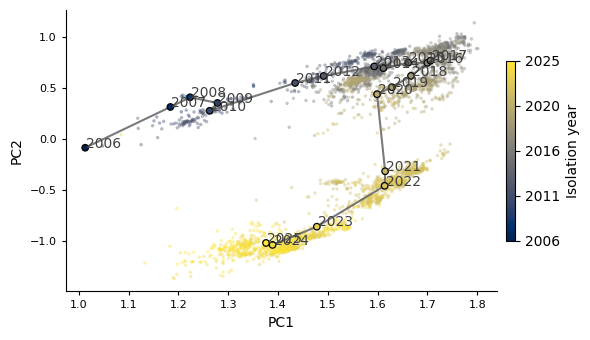

In [7]:
plot_df_filt = plot_df[plot_df['type'].isin(['H3N2', 'H3N2_2024NH', 'H3N2_2024SH', 'H3N2_2025NH'])]
# plot_df_filt = plot_df_filt[plot_df_filt['x'] > 1.1]
# plot_df_filt = plot_df_filt[plot_df_filt['y'] < 1]
# plot_virus_scatter_time(plot_df_filt, color_quantile=(0, 1), label_centroid=False, save_path='H3N2_evo.png')
plot_virus_scatter_time(plot_df_filt, color_quantile=(0, 1))